# Marketing Funnel & Lead Scoring Analysis

This notebook provides a comprehensive analysis of the marketing funnel. The goal is to track the progression of leads from initial contact to final conversion, identifying key drop-off points and evaluating the performance of various acquisition channels.

In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Acquisition and Preprocessing

In this section, we load the raw lead scoring data and perform essential cleaning steps, including handling missing values and removing duplicates to ensure data quality for the analysis.

In [4]:
RAW_PATH = "../data/raw/lead_scoring.csv"

def load_and_clean_data(path):
    if not os.path.exists(path):
        # Try root path if running from root
        path = "data/raw/lead_scoring.csv"
        
    df = pd.read_csv(path).replace("Select", np.nan)
    
    # Drop high-null columns (>40%)
    limit = 0.40
    null_pct = df.isnull().mean()
    to_drop = null_pct[null_pct > limit].index.tolist()
    df = df.drop(columns=to_drop)
    
    # Simple imputation: Median for numbers, Mode for categories
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(exclude=np.number).columns
    
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    return df.drop_duplicates()

df = load_and_clean_data(RAW_PATH)
print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Data Loaded: 9240 rows, 30 columns


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,No,No,Interested in other courses,No,No,Mumbai,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,No,No,Ringing,No,No,Mumbai,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,No,No,Will revert after reading the email,No,No,Mumbai,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,No,No,Ringing,No,No,Mumbai,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,No,No,Will revert after reading the email,No,No,Mumbai,No,No,Modified


## 2. Feature Engineering and Funnel Logic

We define the sequential stages of our marketing funnel: **Visitors**, **Engaged**, **Qualified**, and **Customers**. Logical flags are applied to the dataset based on engagement metrics like time spent and pages viewed.

In [5]:
def apply_funnel_logic(df):
    # 3. Customer: Successfully Converted
    df["Customer"] = df["Converted"] == 1
    
    # 2. Qualified: Behavioral qualification OR Customer
    df["Qualified"] = ((df["Total Time Spent on Website"] > 300) & (df["Page Views Per Visit"].astype(float) > 3)) | df["Customer"]
    
    # 1. Engaged: Spent time OR is Qualified
    df["Engaged"] = (df["Total Time Spent on Website"] > 300) | df["Qualified"]
    
    metrics = {
        "Total Visitors": len(df),
        "Total Engaged": int(df["Engaged"].sum()),
        "Total Qualified": int(df["Qualified"].sum()),
        "Total Customers": int(df["Customer"].sum()),
    }
    
    v, e, q, c = metrics.values()
    metrics["Overall Conversion (%)"] = round((c / v) * 100, 2) if v else 0
    
    return df, metrics

df, metrics = apply_funnel_logic(df)
print("Funnel Metrics:", metrics)

Funnel Metrics: {'Total Visitors': 9240, 'Total Engaged': 5507, 'Total Qualified': 4156, 'Total Customers': 3561, 'Overall Conversion (%)': 38.54}


## 3. Marketing Funnel Visualizations

The following charts visualize the funnel from different perspectives, highlighting conversion rates and volume across each stage.

### Interactive Funnel Overview

Using Plotly to create a dynamic view of the funnel, showing percentage retention between adjacent stages and cumulative conversion from the start.

In [6]:
stages = ["Visitors", "Engaged", "Qualified", "Customers"]
vals = [metrics["Total Visitors"], metrics["Total Engaged"], metrics["Total Qualified"], metrics["Total Customers"]]

fig = go.Figure(go.Funnel(
    y = stages,
    x = vals,
    textinfo = "value+percent initial+percent previous",
    marker = {"color": ["#3366CC", "#DC3912", "#FF9900", "#109618"]},
    connector = {"line": {"color": "royalblue", "width": 4}}
))

fig.update_layout(
    title_text="Marketing Funnel Analysis",
    title_x=0.5,
    template="plotly_white",
    font=dict(family="Arial", size=14)
)

fig.show()

### Funnel Summary (Horizontal Progression)

A simplified horizontal representation of the funnel stage counts and their respective conversion percentages relative to the total visitor base.

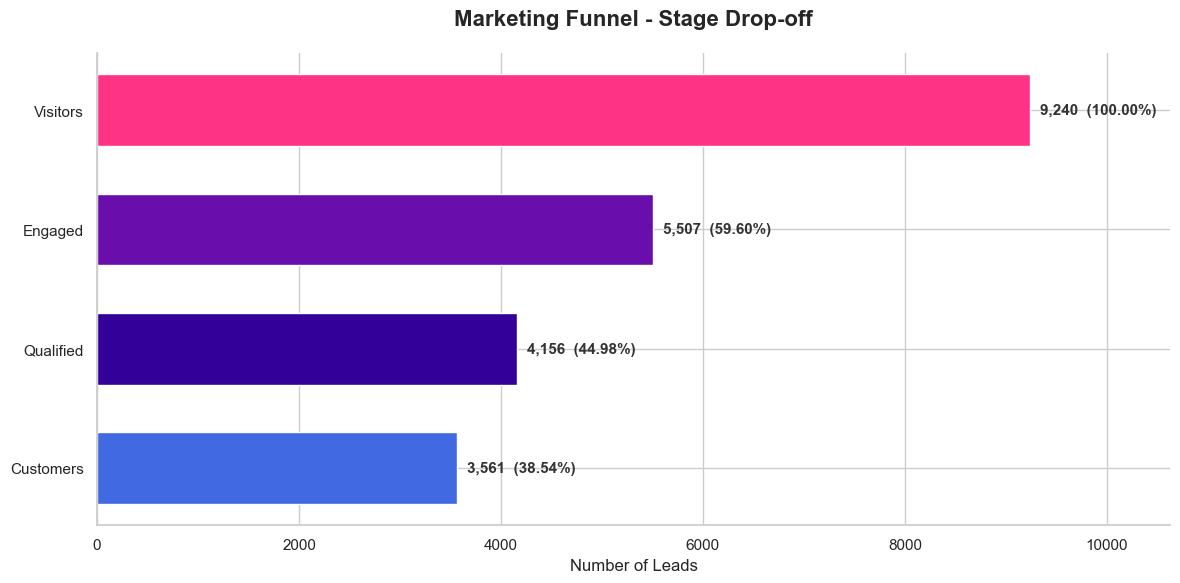

In [10]:
# Stage Drop-off Analysis (Horizontal Bar Chart)
stages = ["Visitors", "Engaged", "Qualified", "Customers"]
vals = [metrics["Total Visitors"], metrics["Total Engaged"], metrics["Total Qualified"], metrics["Total Customers"]]
percentages = [(v / vals[0] * 100) for v in vals]

plt.figure(figsize=(12, 6))
colors = ["#ff3385", "#6a0dad", "#330099", "#4169e1"]
bars = plt.barh(stages[::-1], vals[::-1], color=colors[::-1], height=0.6)

plt.title("Marketing Funnel - Stage Drop-off", weight="bold", size=16, pad=20)
plt.xlabel("Number of Leads", size=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add text labels
for bar, val, pct in zip(bars, vals[::-1], percentages[::-1]):
    plt.text(val + 100, bar.get_y() + bar.get_height()/2, f"{val:,}  ({pct:.2f}%)", 
             va='center', fontweight='bold', color='#333333', size=11)

plt.xlim(0, max(vals) * 1.15)
plt.tight_layout()
plt.show()

### Stage Transition Drop-off Analysis

This visualization focuses on lean loss. It identifies where the most significant number of leads exit the funnel, pinpointing specific areas for optimization.

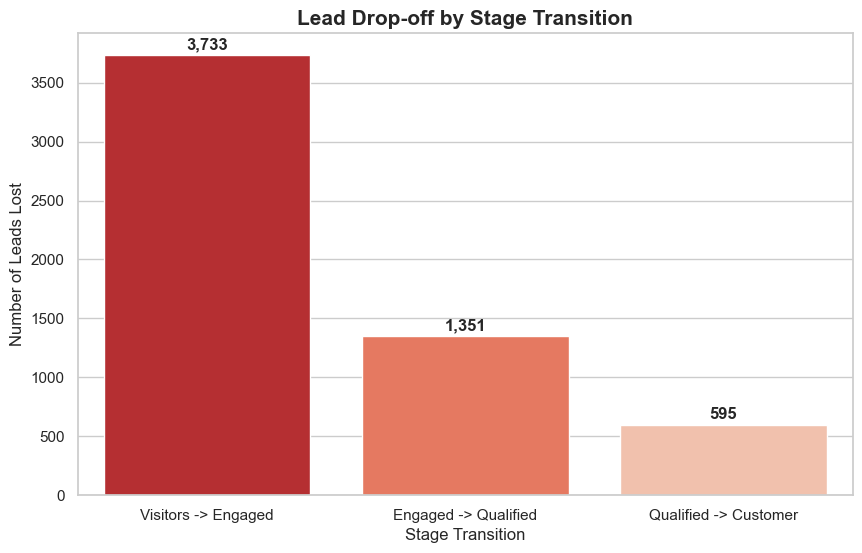

The biggest drop-off occurs at: Visitors -> Engaged (3,733 leads lost)


In [9]:
dropoffs = {
    "Visitors -> Engaged": metrics["Total Visitors"] - metrics["Total Engaged"],
    "Engaged -> Qualified": metrics["Total Engaged"] - metrics["Total Qualified"],
    "Qualified -> Customer": metrics["Total Qualified"] - metrics["Total Customers"]
}

dropoff_df = pd.DataFrame(list(dropoffs.items()), columns=["Stage Transition", "Leads Lost"])

plt.figure(figsize=(10, 6))
sns.barplot(data=dropoff_df, x="Stage Transition", y="Leads Lost", hue="Stage Transition", palette="Reds_r", legend=False)
plt.title("Lead Drop-off by Stage Transition", weight="bold", size=15)
plt.ylabel("Number of Leads Lost")
for i, val in enumerate(dropoff_df["Leads Lost"]):
    plt.text(i, val + 50, f"{val:,}", ha="center", fontweight="bold")
plt.show()

biggest_drop = max(dropoffs, key=dropoffs.get)
print(f"The biggest drop-off occurs at: {biggest_drop} ({dropoffs[biggest_drop]:,} leads lost)")

### Static Funnel Breakdown

A standard volume-based comparison of the total number of leads present at each stage of the journey.

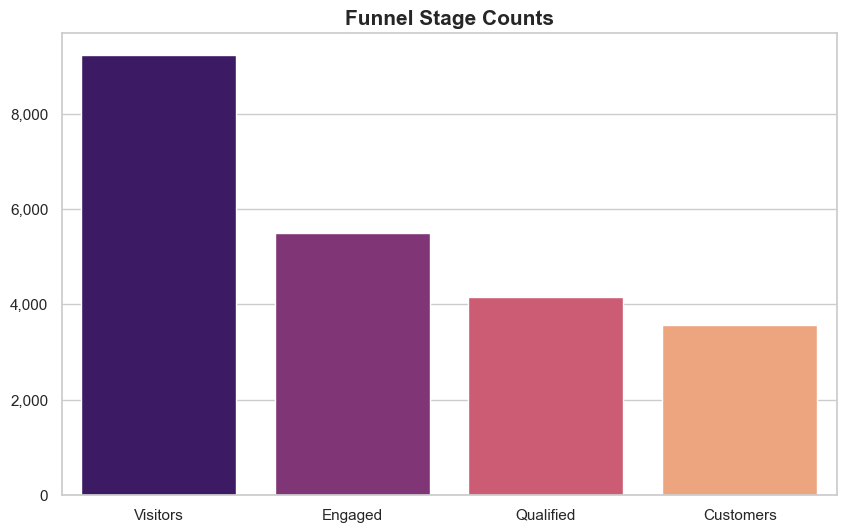

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=stages, y=vals, hue=stages, palette="magma", legend=False)
plt.title("Funnel Stage Counts", weight="bold", size=15)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.show()

## 4. Lead Source and Channel Performance

We drill down into the conversion rates across different marketing channels to identify which sources provide the highest quality leads and the best return on engagement.

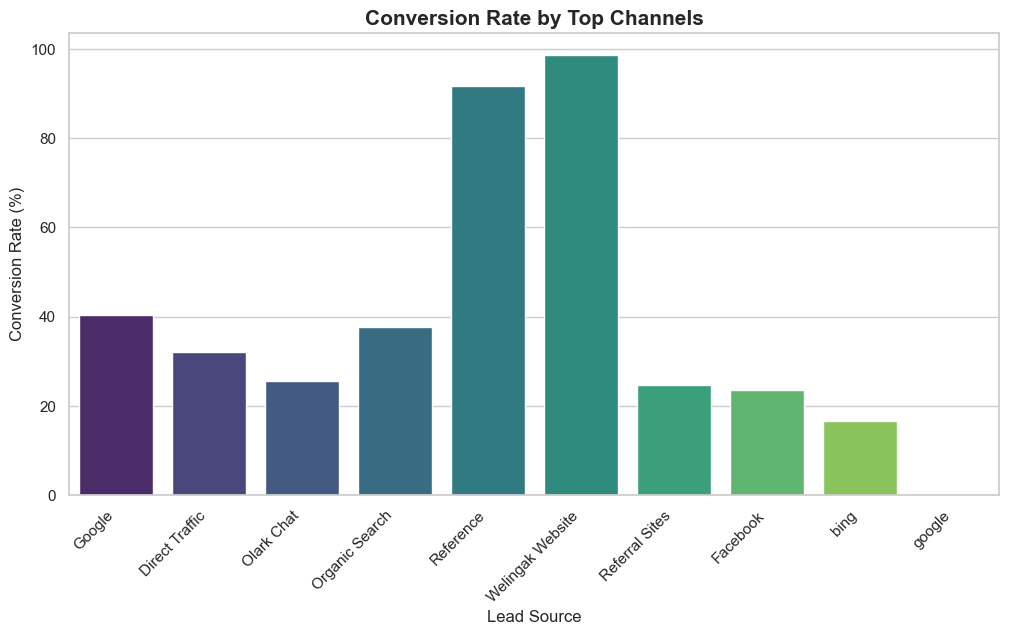

In [7]:
channel_df = df.groupby("Lead Source").agg(
    Total_Leads=("Converted", "count"),
    Converted_Leads=("Converted", "sum")
).reset_index()

channel_df["Conversion_Rate (%)"] = round((channel_df["Converted_Leads"] / channel_df["Total_Leads"]) * 100, 2)

# Filter for top channels by volume
top_channels = channel_df.sort_values("Total_Leads", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_channels, x="Lead Source", y="Conversion_Rate (%)", hue="Lead Source", palette="viridis", legend=False)
plt.title("Conversion Rate by Top Channels", weight="bold", size=15)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Conversion Rate (%)")
plt.show()